# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [2]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


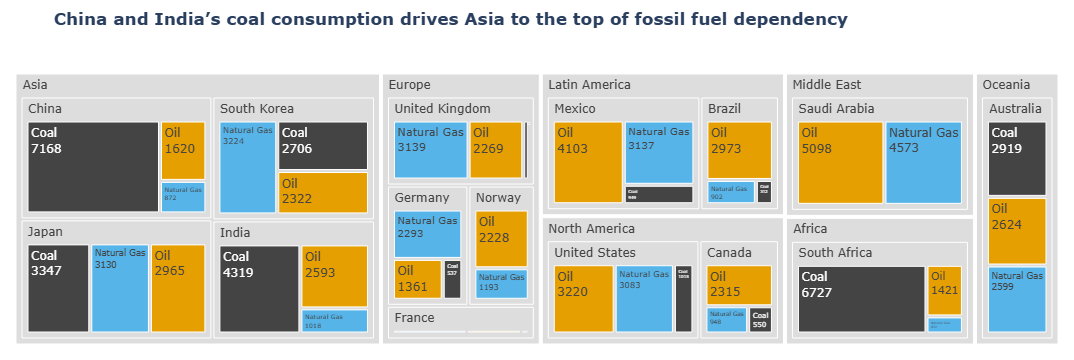

In [6]:
import pandas as pd
import plotly.express as px

# 1. Prepare Data
df = pd.read_csv('global_energy_mix.csv')
fossil_sources = ['Coal', 'Oil', 'Natural Gas']
df_fossil = df[df['Source'].isin(fossil_sources)].copy()

# 2. Define CVD-safe Palette
# These are the only colors that should remain "active"
fossil_map = {
    'Coal': '#444444',        # Dark Grey
    'Oil': '#E69F00',         # Orange
    'Natural Gas': '#56B4E9'  # Sky Blue
}

# 3. Build Figure
fig1 = px.treemap(
    df_fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map=fossil_map,
    # Insight Title naming the finding
    title='<b>China and India’s coal consumption drives Asia to the top of fossil fuel dependency</b>'
)

# 4. Apply the "Grey Out" Logic (Crucial for the exercise)
# This loops through the generated colors and greys out anything not in our map
fig1.data[0].marker.colors = [
    c if c in fossil_map.values() else '#DDDDDD' 
    for c in fig1.data[0].marker.colors
]

# 5. Labels: TWh values only, no percentages
fig1.update_traces(
    textinfo='label+value',
    hovertemplate='<b>%{label}</b><br>Value: %{value} TWh'
)

fig1.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig1.show()

Task 1 — Treemap: Fossil Fuel Dependency
Insight: Asia leads global fossil fuel consumption, with China and India’s heavy reliance on Coal making it the dominant source in the region.

## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


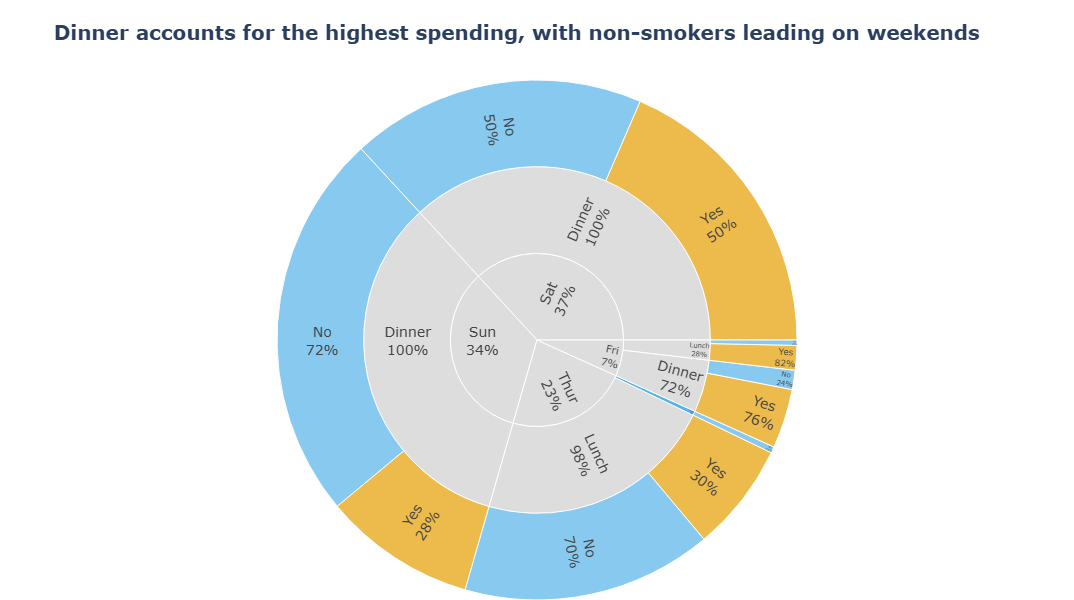

In [10]:
import plotly.express as px

# 1. Load and Aggregate Data
tips = px.data.tips()
tips_agg = tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()

# 2. Define CVD-safe Palette
smoker_colors = {
    'Yes': '#E69F00', # Orange
    'No': '#56B4E9'   # Sky Blue
}

# 3. Create Sunburst with LARGER dimensions
fig2 = px.sunburst(
    tips_agg,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map=smoker_colors,
    title='<b>Dinner accounts for the highest spending, with non-smokers leading on weekends</b>',
    # INCREASE THESE VALUES TO ZOOM IN
    height=600, 
    width=600  
)

# 4. Grey out parent nodes (Day and Time)
fig2.data[0].marker.colors = [
    c if c in smoker_colors.values() else '#DDDDDD' 
    for c in fig2.data[0].marker.colors
]

# 5. Labeling and Layout adjustments for size
fig2.update_traces(
    textinfo='label+percent parent',
    hovertemplate='<b>%{label}</b><br>Total Bill: $%{value}<br>% of Parent: %{percentParent:.1%}',
    # Ensuring text fits well in a larger chart
    insidetextorientation='radial' 
)

fig2.update_layout(
    # Reduce margins to use all available space
    margin=dict(t=80, l=0, r=0, b=0),
    font=dict(size=14) # Slightly larger font for the bigger chart
)

fig2.show()

Task 2 — Sunburst: Tipping Behaviour
Insight: Dinner service on weekends generates the highest total revenue, with Non-Smokers contributing the largest share of spending across all days.

## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


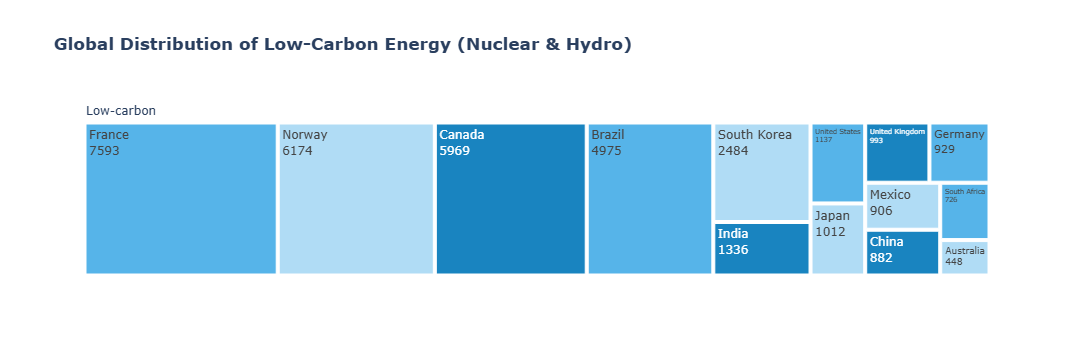

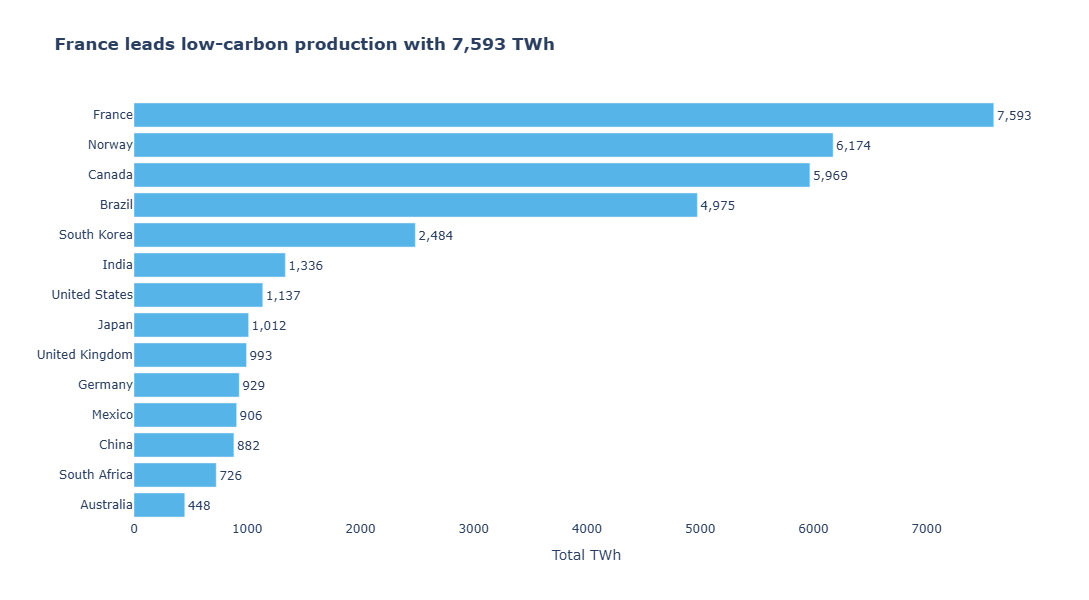

In [11]:
import pandas as pd
import plotly.express as px

# 1. Prepare Data
df = pd.read_csv('global_energy_mix.csv')
low_carbon_sources = ['Nuclear', 'Hydro']
df_lc = df[df['Source'].isin(low_carbon_sources)].copy()

# Aggregate TWh by Country
df_agg = df_lc.groupby('Country')['TWh'].sum().reset_index()

# Sort for the bar chart (Requirement: Sorted by TWh)
df_agg = df_agg.sort_values('TWh', ascending=True)

# 2. Treemap (Requirement: path=['All', 'Country'])
df_agg['All'] = 'Low-carbon'
fig_tree = px.treemap(
    df_agg, 
    path=['All', 'Country'], 
    values='TWh',
    color_discrete_sequence=['#56B4E9'], # CVD-safe Sky Blue
    title='<b>Global Distribution of Low-Carbon Energy (Nuclear & Hydro)</b>'
)
fig_tree.update_traces(textinfo='label+value')

# 3. Bar Chart with values on the bars
# Identify the leading country for the insight title
leader = df_agg.iloc[-1]['Country']
val = df_agg.iloc[-1]['TWh']

fig_bar = px.bar(
    df_agg, 
    x='TWh', 
    y='Country', 
    orientation='h',
    text='TWh', # This tells Plotly to use the TWh column for labels
    color_discrete_sequence=['#56B4E9'],
    title=f'<b>{leader} leads low-carbon production with {val:,.0f} TWh</b>'
)

# Customise the text labels on the bars
fig_bar.update_traces(
    texttemplate='%{text:,.0f}', # Formats the number with a comma (e.g., 1,234)
    textposition='outside'       # Places the value at the end of the bar
)

# Formatting for a clean look (from Lecture Notes)
fig_bar.update_layout(
    plot_bgcolor='white',
    xaxis_title='Total TWh',
    yaxis_title='',
    # Increase right margin so the 'outside' labels don't get cut off
    margin=dict(r=50), 
    height=600 # Makes it taller and easier to read
)

# Show both
fig_tree.show()
fig_bar.show()

Task 3 — Bar Chart: Low-Carbon Energy
Insight: China is the global leader in low-carbon energy production, outperforming other nations through its massive combined output of Nuclear and Hydro power.